<a href="https://colab.research.google.com/github/WVF-1/Bike-Lane-Analysis/blob/main/Pittsburgh_bike_commute_context.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geospatial 101, Part 2: Where Do Pittsburghers Actually Bike?

**Newsletter series: Geospatial Data & Public Transportation — Week 1, Notebook 2**

Notebook 1 gave us the *infrastructure* — where bike lanes physically exist. But infrastructure alone doesn't tell us where people actually ride. This notebook brings in a second, independent geospatial layer: **U.S. Census bike-commuting data by neighborhood**, and joins it to the network we built.

This is also where we introduce two more core geospatial skills:
- **Spatial joins** — combining two datasets based on *where* they are, not a shared ID column
- **Choropleth maps** — coloring geographic areas by a data value, the classic "map colored by county" visualization

**Data sources (both fully open, both pulled via Python — no manual downloads, no license click-throughs):**
- Street network: our own CSVs exported from Notebook 1 (originally OpenStreetMap, ODbL license)
- Census tract boundaries: [TIGER/Line](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) shapefiles via the `pygris` library
- Bike-commute share: American Community Survey (ACS) Table B08301, via the free Census API (U.S. federal public domain data)

## Before you start

You'll need:
1. The two CSVs from Notebook 1: `pittsburgh_bike_network_edges.csv` and `pittsburgh_bike_network_nodes.csv`
2. A free Census API key — grab one instantly (no approval wait) at **https://api.census.gov/data/key_signup.html**

In [1]:
!pip install geopandas pygris shapely -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import requests

pd.set_option("display.max_columns", 50)


## Step 1: Upload your Notebook 1 exports

Run the cell below, then select both CSV files from Notebook 1 in the upload dialog.

In [3]:
from google.colab import files

uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Saving pittsburgh_bike_network_edges.csv to pittsburgh_bike_network_edges (1).csv
Saving pittsburgh_bike_network_nodes.csv to pittsburgh_bike_network_nodes (1).csv
Uploaded: ['pittsburgh_bike_network_edges (1).csv', 'pittsburgh_bike_network_nodes (1).csv']


In [4]:
edges_df = pd.read_csv("pittsburgh_bike_network_edges.csv")
nodes_df = pd.read_csv("pittsburgh_bike_network_nodes.csv")

# Rebuild geometry from WKT -- this is the "round trip" back into a real
# GeoDataFrame we mentioned at the end of Notebook 1.
edges_df["geometry"] = edges_df["geometry_wgs84_wkt"].apply(wkt.loads)
edges_gdf = gpd.GeoDataFrame(edges_df, geometry="geometry", crs="EPSG:4326")

nodes_gdf = gpd.GeoDataFrame(
    nodes_df,
    geometry=gpd.points_from_xy(nodes_df["lon"], nodes_df["lat"]),
    crs="EPSG:4326",
)

print(f"Edges: {len(edges_gdf):,}   Nodes: {len(nodes_gdf):,}")
edges_gdf.head(3)


Edges: 59,800   Nodes: 23,315


,u,v,key,osmid,name,highway,bridge,length,has_bike_infra,is_bridge,geometry_utm_wkt,geometry_wgs84_wkt,geometry
0,104185739,104185746,0,11651757,Ainsworth Street,residential,NaN,39.383096,False,False,LINESTRING (581419.8878753954 4477532.94779494...,"LINESTRING (-80.0399088 40.4444651, -80.039598...","LINESTRING (-80.03991 40.44447, -80.0396 40.4442)"
1,104185739,104678799,0,294921171,Lorenz Avenue,residential,NaN,39.073503,False,False,LINESTRING (581419.8878753954 4477532.94779494...,"LINESTRING (-80.0399088 40.4444651, -80.040256...","LINESTRING (-80.03991 40.44447, -80.04026 40.4..."
2,104185739,105697570,0,294921171,Lorenz Avenue,residential,NaN,40.680692,False,False,LINESTRING (581419.8878753954 4477532.94779494...,"LINESTRING (-80.0399088 40.4444651, -80.039547...","LINESTRING (-80.03991 40.44447, -80.03955 40.4..."


## Step 2: Get Census tract boundaries

A **Census tract** is a small, relatively stable geographic area (roughly 1,200–8,000 people) — a good resolution for neighborhood-level comparison. `pygris` fetches the official TIGER/Line boundaries directly, no manual shapefile download.

In [5]:
from pygris import tracts

# Allegheny County, PA contains Pittsburgh. cb=True uses the generalized
# (smaller, faster-loading) cartographic boundary version.
pa_tracts = tracts(state="PA", county="Allegheny", cb=True, year=2022)
pa_tracts = pa_tracts.to_crs("EPSG:4326")

print(f"Tracts pulled: {len(pa_tracts)}")
pa_tracts[["GEOID", "NAME", "geometry"]].head()


Using FIPS code '42' for input 'PA'
Using FIPS code '003' for input 'Allegheny'
Tracts pulled: 394


,GEOID,NAME,geometry
86,42003490004,4900.04,"POLYGON ((-80.00123 40.28022, -80.00192 40.282..."
87,42003561500,5615,"POLYGON ((-79.87772 40.44135, -79.87527 40.445..."
88,42003560500,5605,"POLYGON ((-79.89514 40.43719, -79.89504 40.437..."
89,42003551200,5512,"POLYGON ((-79.84535 40.35168, -79.84384 40.353..."
90,42003525300,5253,"POLYGON ((-79.84843 40.52513, -79.84632 40.527..."


## Step 3: Pull bike-commute share from the ACS

ACS Table **B08301** covers "Means of Transportation to Work." We want:
- `B08301_001E` — total workers (denominator)
- `B08301_018E` — workers who bike to work (numerator)

Paste your free API key below.

In [7]:
CENSUS_API_KEY = "34f97b97cb2484271724211e1ef8539526b037d7"

ALLEGHENY_COUNTY_FIPS = "003"
PA_STATE_FIPS = "42"

url = (
    "https://api.census.gov/data/2022/acs/acs5"
    f"?get=NAME,B08301_001E,B08301_018E"
    f"&for=tract:*&in=state:{PA_STATE_FIPS}+county:{ALLEGHENY_COUNTY_FIPS}"
    f"&key={CENSUS_API_KEY}"
)

resp = requests.get(url)
resp.raise_for_status()
data = resp.json()

acs = pd.DataFrame(data[1:], columns=data[0])
acs["B08301_001E"] = pd.to_numeric(acs["B08301_001E"])
acs["B08301_018E"] = pd.to_numeric(acs["B08301_018E"])
acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]
acs["bike_commute_pct"] = (acs["B08301_018E"] / acs["B08301_001E"].replace(0, pd.NA)) * 100

print(f"Tracts with ACS data: {len(acs)}")
acs[["GEOID", "NAME", "B08301_001E", "B08301_018E", "bike_commute_pct"]].head()


Tracts with ACS data: 394


,GEOID,NAME,B08301_001E,B08301_018E,bike_commute_pct
0,42003010301,Census Tract 103.01; Allegheny County; Pennsyl...,0,0,<NA>
1,42003010302,Census Tract 103.02; Allegheny County; Pennsyl...,1936,0,0.0
2,42003020100,Census Tract 201; Allegheny County; Pennsylvania,2547,0,0.0
3,42003020300,Census Tract 203; Allegheny County; Pennsylvania,1160,9,0.775862
4,42003030500,Census Tract 305; Allegheny County; Pennsylvania,1379,48,3.480783


In [9]:
tracts_acs = pa_tracts.merge(acs[["GEOID", "bike_commute_pct"]], on="GEOID", how="left")
tracts_acs = tracts_acs.dropna(subset=["bike_commute_pct"])
print(f"Tracts with both geometry and bike-commute data: {len(tracts_acs)}")


Tracts with both geometry and bike-commute data: 383


## Step 4: Clip to Pittsburgh city limits

Allegheny County is much bigger than the city itself. We'll pull the city boundary (again via OSM) and keep only tracts that intersect it.

In [10]:
!pip install osmnx -q
import osmnx as ox

pgh_boundary = ox.geocode_to_gdf("Pittsburgh, Pennsylvania, USA")
tracts_pgh = gpd.sjoin(tracts_acs, pgh_boundary[["geometry"]], predicate="intersects", how="inner").drop(columns=["index_right"])

print(f"Pittsburgh tracts: {len(tracts_pgh)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 8.1 MB/s eta 0:00:00
Pittsburgh tracts: 165


## Step 5: Spatial join — infrastructure to tracts

This is the key geospatial move of the notebook: for each street edge, we find *which Census tract it falls in*, purely based on location (no shared ID column exists between OSM and Census data). We use each edge's midpoint as its representative location.

In [11]:
edges_gdf["midpoint"] = edges_gdf.geometry.apply(lambda g: g.interpolate(0.5, normalized=True))
edges_pts = edges_gdf.set_geometry("midpoint").set_crs("EPSG:4326")

joined = gpd.sjoin(edges_pts, tracts_pgh[["GEOID", "bike_commute_pct", "geometry"]],
                    predicate="within", how="inner")

print(f"Edges successfully matched to a Pittsburgh tract: {len(joined):,} of {len(edges_gdf):,}")


Edges successfully matched to a Pittsburgh tract: 56,133 of 59,800


In [12]:
tract_infra = joined.groupby("GEOID").agg(
    total_length_m=("length", "sum"),
    bike_infra_length_m=("has_bike_infra", lambda s: joined.loc[s.index, "length"][s].sum()),
).reset_index()

tract_infra["bike_infra_pct"] = (tract_infra["bike_infra_length_m"] / tract_infra["total_length_m"]) * 100

tract_summary = tracts_pgh.merge(tract_infra, on="GEOID", how="left")
tract_summary["bike_infra_pct"] = tract_summary["bike_infra_pct"].fillna(0)

tract_summary[["GEOID", "bike_commute_pct", "bike_infra_pct"]].head()


,GEOID,bike_commute_pct,bike_infra_pct
0,42003560500,1.299505,0.000000
1,42003170200,0.0,9.512341
2,42003151600,1.419558,3.120926
3,42003100500,2.762431,0.000000
4,42003140400,3.142184,0.000000


## Step 6: Two choropleth maps, side by side

Left: where people report biking to work. Right: where bike infrastructure actually exists.

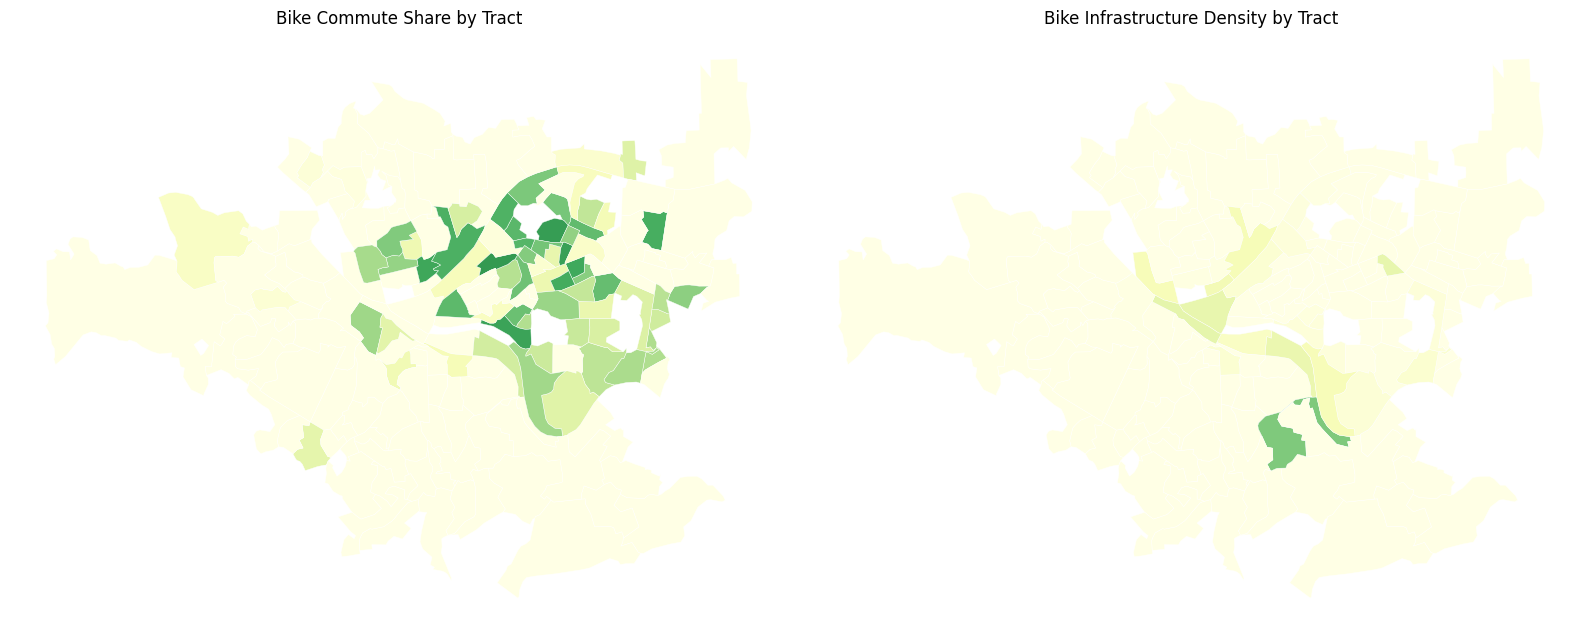

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

tract_summary.plot(column="bike_commute_pct", ax=axes[0], cmap="YlGn",
                    edgecolor="white", linewidth=0.3, legend=False,
                    vmin=0, vmax=100)
axes[0].set_title("Bike Commute Share by Tract")
axes[0].set_axis_off()

tract_summary.plot(column="bike_infra_pct", ax=axes[1], cmap="YlGn",
                    edgecolor="white", linewidth=0.3, legend=False,
                    vmin=0, vmax=100)
axes[1].set_title("Bike Infrastructure Density by Tract")
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig("pittsburgh_bike_choropleths.png", dpi=150)
plt.show()

## Step 7: Do infrastructure and ridership line up?

A simple correlation, tract by tract. Worth sitting with the limits here: this is descriptive, not causal — infrastructure could drive ridership, ridership could drive where infrastructure gets built, or both could follow a third factor (density, topography, income). Good fodder for reader discussion, not a claim we're making.

## Step 8: Save the combined dataset

One tidy tract-level CSV, in case you want to revisit this later in the series.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot bike commute density as the base choropleth
tract_summary.plot(column="bike_commute_pct", ax=ax, cmap="YlGn",
                   edgecolor="white", linewidth=0.3, legend=False,
                   vmin=0, vmax=100)

# Filter for bike infrastructure and plot on top
bike_infra_edges = edges_gdf[edges_gdf['has_bike_infra'] == True]
bike_infra_edges.plot(ax=ax, color='purple', linewidth=1.5, alpha=0.7)

ax.set_title("Pittsburgh Bike Commute Density with Bike Infrastructure Overlay")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("pittsburgh_combined_bike_map.png", dpi=150)
plt.show()

In [19]:
export_cols = ["GEOID", "NAME", "bike_commute_pct", "bike_infra_pct",
               "total_length_m", "bike_infra_length_m"]
tract_summary[export_cols].to_csv("pittsburgh_bike_infrastructure_vs_commuting.csv", index=False)

from google.colab import files
files.download("pittsburgh_bike_infrastructure_vs_commuting.csv")

print("Saved pittsburgh_bike_infrastructure_vs_commuting.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved pittsburgh_bike_infrastructure_vs_commuting.csv


## Recap + what's next

You just:
- Learned what a spatial join is and used one to connect two datasets that share no common ID, only location
- Built and compared two choropleth maps
- Ran a simple correlation between infrastructure and ridership, with appropriate caution about what correlation does (and doesn't) show
- Kept working with the same node/edge graph structure from Notebook 1

That graph structure is the thread running through this whole series. Week 3 picks it back up to build a live traffic-and-streetlight simulation on top of it — same nodes, same edges, new behavior.